In [317]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

In [318]:
df = pd.read_csv("../data/raw/hotel_bookings.csv")
print("Dataset shape:",df.shape)

Dataset shape: (119390, 32)


In [ ]:
df.head()

In [320]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.describe()

In [ ]:
df.describe(include='object')

In [ ]:
df.dtypes

In [319]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [321]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
hotel,0,0.000000
is_canceled,0,0.000000
stays_in_weekend_nights,0,0.000000
arrival_date_day_of_month,0,0.000000


In [322]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 31994


In [323]:
df.nunique()

hotel                                2
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_month                  12
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
assigned_room_type                  12
booking_changes                     21
deposit_type                         3
agent                              333
company                            352
days_in_waiting_list     

In [324]:
df['is_canceled'].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [325]:
(df['is_canceled'].value_counts(normalize=True))*100

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

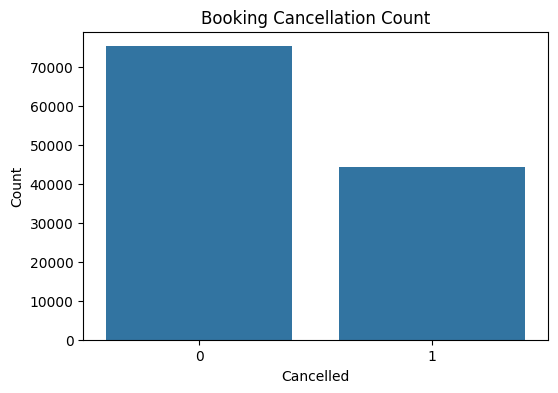

In [326]:
plt.figure(figsize=(6,4))

sns.countplot(x='is_canceled', data=df)

plt.title("Booking Cancellation Count")
plt.xlabel("Cancelled")
plt.ylabel("Count")

plt.show()

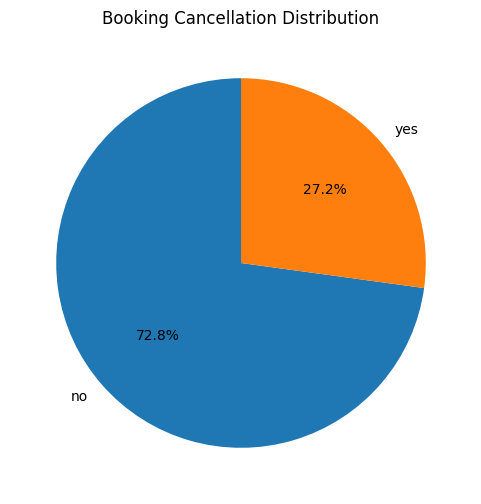

In [357]:
plt.figure(figsize=(6,6))

df['is_canceled'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel("")
plt.title("Booking Cancellation Distribution")

plt.show()

In [ ]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

print(numerical_columns)


Observation:
- Dataset contains 119390 rows and 32 columns.
- The target variable is 'is_canceled'.
- Some columns contain missing values.
- The dataset contains both numerical and categorical variables.
- Duplicate records are present and need to be handled.

Data cleaning

In [327]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
})

missing.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
hotel,0,0.000000
is_canceled,0,0.000000
stays_in_weekend_nights,0,0.000000
arrival_date_day_of_month,0,0.000000


In [328]:
# Fill missing values

df['children'].fillna(df['children'].median(), inplace=True)
df['country'].fillna(df['country'].mode()[0], inplace=True)
df.drop(columns=['company'], inplace=True)
df['agent'].fillna(0, inplace=True)

In [ ]:
df.isnull().sum()

In [329]:
 #Duplicate rows
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

Duplicates: 32020
New Shape: (87370, 31)


In [330]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

EDA

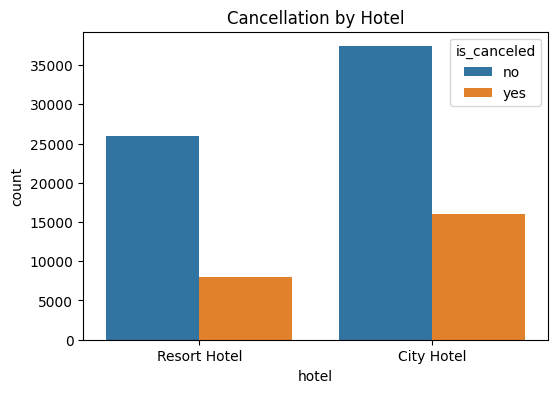

In [331]:
plt.figure(figsize=(6,4))
df['is_canceled'] = df['is_canceled'].map({0: 'no', 1: 'yes'})
sns.countplot(x='hotel', hue='is_canceled', data=df)
plt.title("Cancellation by Hotel")
plt.show()

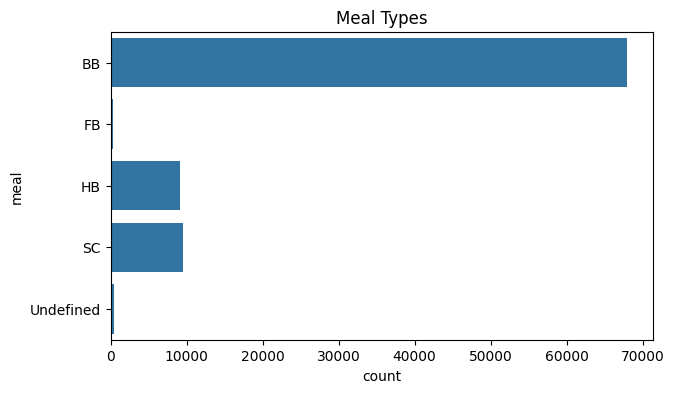

In [332]:
plt.figure(figsize=(7,4))
sns.countplot(y='meal', data=df)
plt.title("Meal Types")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(y='market_segment', data=df)
plt.title("Market Segment")
plt.show()

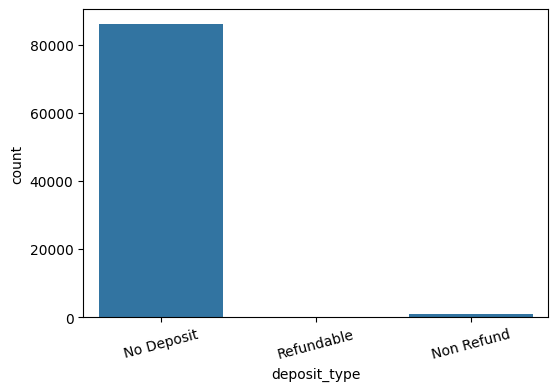

In [333]:
plt.figure(figsize=(6,4))
sns.countplot(x='deposit_type', data=df)
plt.xticks(rotation=15)
plt.show()

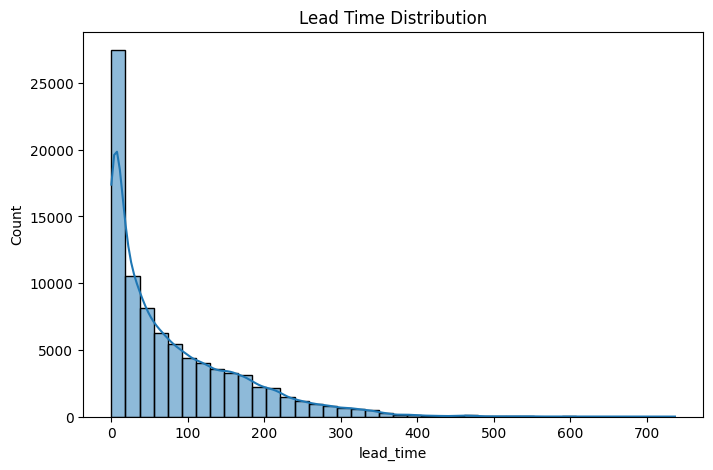

In [334]:
plt.figure(figsize=(8,5))
sns.histplot(df['lead_time'], bins=40, kde=True)
plt.title("Lead Time Distribution")
plt.show()

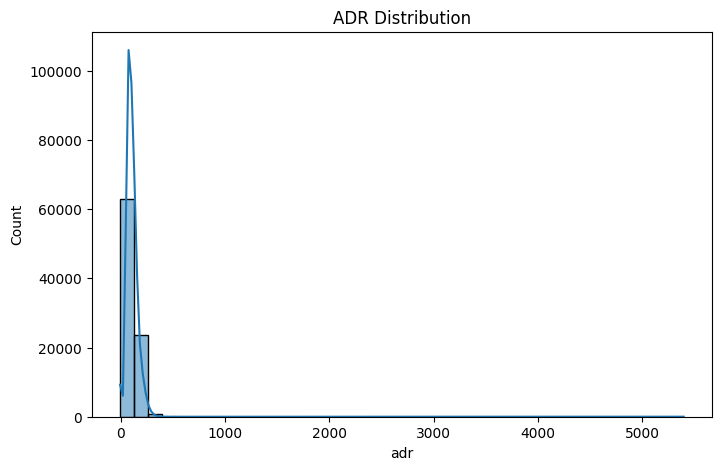

In [335]:
plt.figure(figsize=(8,5))
sns.histplot(df['adr'], bins=40, kde=True)
plt.title("ADR Distribution")
plt.show()

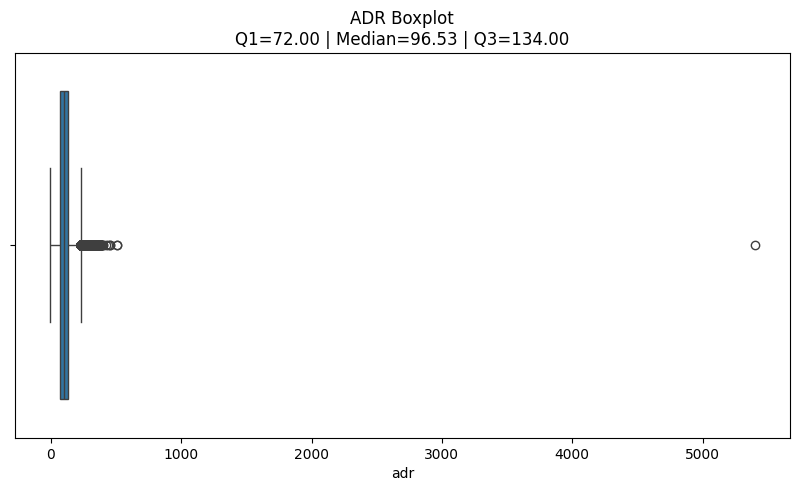

In [336]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(x=df['adr'])

plt.title(
    f"ADR Boxplot\n"
    f"Q1={Q1:.2f} | Median={Q2:.2f} | Q3={Q3:.2f}"
)

plt.show()

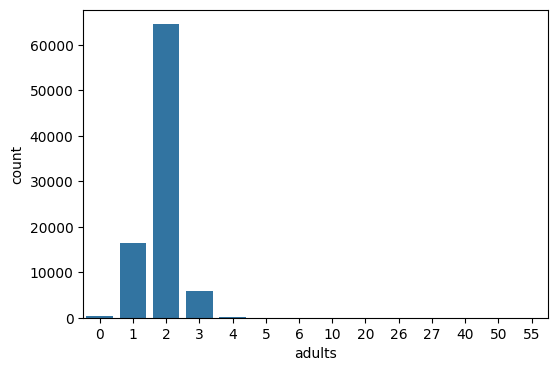

In [337]:
plt.figure(figsize=(6,4))
sns.countplot(x='adults', data=df)
plt.show()

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

Feature engineering

In [338]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']

In [339]:
df['total_stay'] =df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [340]:
months = {
1:'January',
2:'February',
3:'March',
4:'April',
5:'May',
6:'June',
7:'July',
8:'August',
9:'September',
10:'October',
11:'November',
12:'December'
}

df['arrival_month'] = df['arrival_date_month']

In [341]:
df[['total_guests','total_stay']].head()

,total_guests,total_stay
0,2.0,0
1,2.0,0
2,1.0,1
3,1.0,1
4,2.0,2


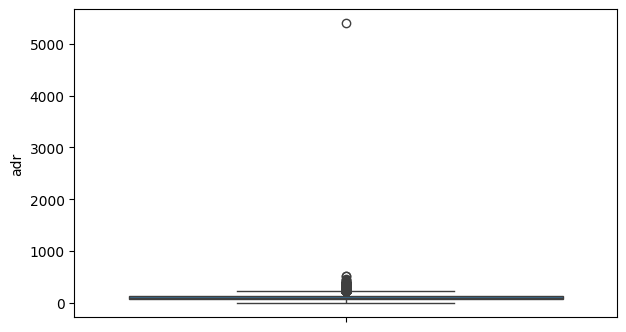

In [342]:
plt.figure(figsize=(7,4))

sns.boxplot(df['adr'])

plt.show()

In [343]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

df = df[(df['adr']>=lower)&(df['adr']<=upper)]

Data preprocessing


In [344]:
df.drop(
    [
        'reservation_status',
        'reservation_status_date'
    ],
    axis=1,
    inplace=True
)

In [345]:
X = df.drop('is_canceled', axis=1)

y = df['is_canceled']

In [346]:
X = pd.get_dummies(X, drop_first=True)

In [347]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [348]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [349]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred_lr))

print(classification_report(y_test,pred_lr))

Accuracy: 0.795782529304353
              precision    recall  f1-score   support

          no       0.82      0.92      0.87     12371
         yes       0.68      0.47      0.56      4606

    accuracy                           0.80     16977
   macro avg       0.75      0.69      0.71     16977
weighted avg       0.78      0.80      0.78     16977



In [350]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred_dt))

print(classification_report(y_test,pred_dt))

Accuracy: 0.8014961418389586
              precision    recall  f1-score   support

          no       0.86      0.86      0.86     12371
         yes       0.63      0.64      0.63      4606

    accuracy                           0.80     16977
   macro avg       0.75      0.75      0.75     16977
weighted avg       0.80      0.80      0.80     16977



In [351]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred_rf))

print(classification_report(y_test,pred_rf))

Accuracy: 0.8451434293455852
              precision    recall  f1-score   support

          no       0.87      0.93      0.90     12371
         yes       0.77      0.62      0.68      4606

    accuracy                           0.85     16977
   macro avg       0.82      0.77      0.79     16977
weighted avg       0.84      0.85      0.84     16977



In [352]:
knn = KNeighborsClassifier()

knn.fit(X_train,y_train)

pred_knn = knn.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred_knn))

print(classification_report(y_test,pred_knn))

Accuracy: 0.769688401955587
              precision    recall  f1-score   support

          no       0.83      0.86      0.85     12371
         yes       0.58      0.52      0.55      4606

    accuracy                           0.77     16977
   macro avg       0.71      0.69      0.70     16977
weighted avg       0.76      0.77      0.77     16977



In [353]:
results = pd.DataFrame({

'Model':['Logistic Regression',
          'Decision Tree',
          'Random Forest',
          'KNN'],

'Accuracy':[

accuracy_score(y_test,pred_lr),

accuracy_score(y_test,pred_dt),

accuracy_score(y_test,pred_rf),

accuracy_score(y_test,pred_knn)

]

})

results.sort_values(by='Accuracy',ascending=False)

,Model,Accuracy
2,Random Forest,0.845143
1,Decision Tree,0.801496
0,Logistic Regression,0.795783
3,KNN,0.769688


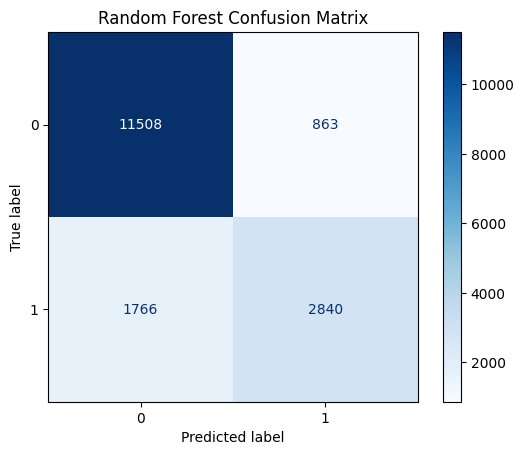

In [354]:
cm = confusion_matrix(y_test,pred_rf)

ConfusionMatrixDisplay(cm).plot(cmap='Blues')

plt.title("Random Forest Confusion Matrix")

plt.show()

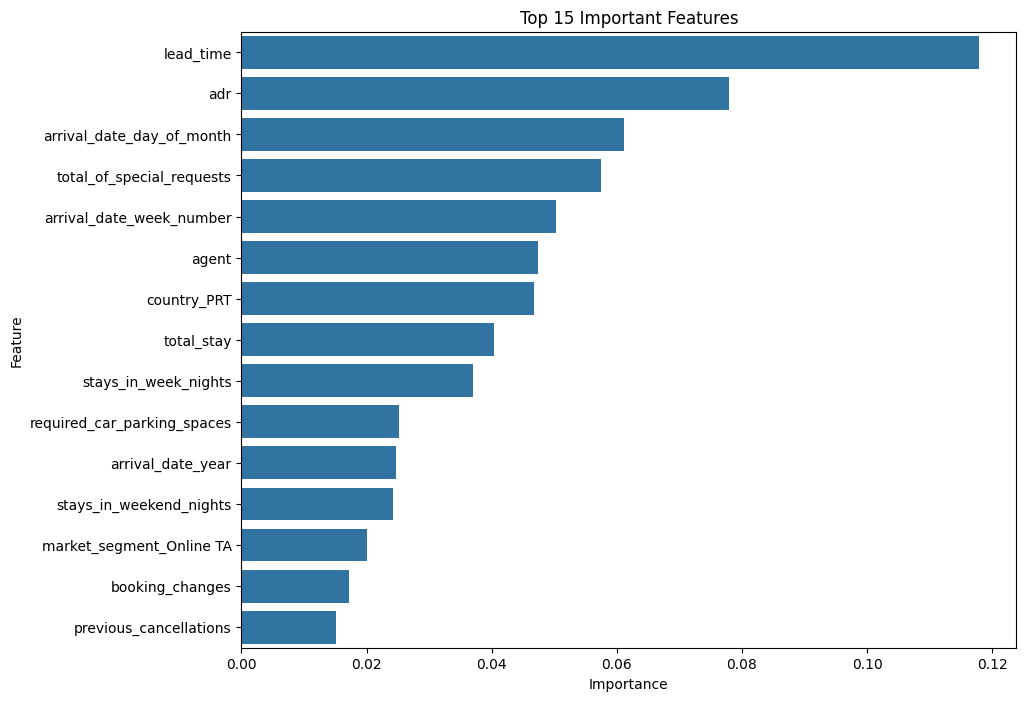

In [355]:
importance = pd.DataFrame({

'Feature':X.columns,
'Importance':rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(15)
)

plt.title("Top 15 Important Features")

plt.show()

In [356]:
import joblib

joblib.dump(rf, "random_forest.pkl")

['random_forest.pkl']

Conclusion:

- The dataset was cleaned by handling missing values, removing duplicates, and correcting data types.
- Exploratory Data Analysis identified important patterns and relationships affecting booking cancellations.
- New features such as total_guests and total_stay were created to improve model performance.
- Multiple classification algorithms were trained and compared.
- The best-performing model was selected based on evaluation metrics such as accuracy, precision, recall, and F1-score.
- Feature importance analysis highlighted the variables that contributed most to predicting booking cancellations.